# Computational Mathematics Assignment — COC351
## Purchase Intention Prediction in E-commerce Using Logistic Regression

**Authors:**
- Matheus Xavier
- Charles Oliveira

## Objective

This project aims to predict the purchase intention of e-commerce session users using a Logistic Regression model. By analyzing behavioral and contextual features — such as pages visited, time spent, traffic source, and visitor type — the model seeks to classify whether a given session will result in a purchase. To address the class imbalance present in the dataset, the SMOTE technique was applied during training. Model performance was evaluated using metrics such as F1-Score, ROC-AUC, and a threshold optimization strategy to maximize predictive accuracy.

## Dataset

**Name:** Online Shoppers Purchasing Intention Dataset
**Source:** UCI Machine Learning Repository
**Link:** https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv

This dataset consists of 12,330 user sessions from an e-commerce platform, where the target variable **Revenue** indicates whether a session resulted in a purchase (15.5% positive, 84.5% negative). It contains 18 attributes divided into four categories:

- **Page Statistics:** number of pages visited and time spent on administrative, informational, and product-related pages.
- **Google Analytics Metrics:** BounceRates, ExitRates, and PageValues.
- **Contextual and Temporal Features:** Month, Weekend, and SpecialDay (proximity to dates such as Valentine's Day).
- **Technical and User Information:** OperatingSystems, Browser, Region, TrafficType, and VisitorType.

## 1. Page Statistics

These features represent the types of pages visited and the time spent on them. They are updated in real-time based on URL information.

* **Administrative**: Number of administrative pages visited in the session.
* **Administrative_Duration**: Total time spent on administrative pages.
* **Informational**: Number of informational pages visited.
* **Informational_Duration**: Total time spent on informational pages.
* **ProductRelated**: Number of product-related pages visited.
* **ProductRelated_Duration**: Total time spent on product-related pages.

## 2. Google Analytics Metrics

These features are derived from standard e-commerce performance metrics.

* **BounceRates**: The percentage of visitors who enter the site from that page and leave ("bounce") without any further requests.
* **ExitRates**: The percentage of views to a page that were the last in the session.
* **PageValues**: The average value of a web page visited before completing a transaction.

## 3. Contextual and Temporal Features

* **SpecialDay**: Indicates the proximity to a special day (e.g., Valentine's Day).
* *Example:* For Valentine's Day, it reaches a maximum value of **1.0** on Feb 8th and returns to **0** after Feb 12th, accounting for shipping/delivery times.


* **Month**: The month of the year in which the session occurred.
* **Weekend**: A Boolean value (True/False) indicating if the visit happened on a weekend.

## 4. Technical and User Information

* **OperatingSystems**: The OS used by the visitor (encoded as integers).
* **Browser**: The browser used by the visitor (encoded as integers).
* **Region**: The geographic region of the visitor.
* **TrafficType**: The source of traffic that brought the user to the site.
* **VisitorType**: Whether the user is a `New_Visitor`, `Returning_Visitor`, or `Other`.

## 5. Target Variable

* **Revenue**: A Boolean value (True/False) indicating whether the session finalized in a purchase.

---

### Dataset Summary Table

| Attribute Category | Count | Type |
| --- | --- | --- |
| **Numerical** | 10 | int64, float64 |
| **Categorical/Other** | 8 | object, bool |
| **Total Samples** | 12,330 | - |

## Methodology

The project follows a structured machine learning pipeline:

1. **Exploratory Data Analysis (EDA):** Initial investigation of the dataset to understand feature distributions, class imbalance, and behavioral patterns across sessions.

2. **Data Preprocessing:** Categorical variables such as `Month` and `VisitorType` were encoded using One-Hot Encoding. Features were standardized using `StandardScaler` to ensure proper convergence of the model.

3. **Class Balancing:** Given the significant class imbalance (84.5% vs 15.5%), the **SMOTE** (Synthetic Minority Oversampling Technique) was applied exclusively on the training set to avoid data leakage.

4. **Logistic Regression:** A Logistic Regression model was trained to estimate the probability of a session resulting in a purchase. The model learns a set of coefficients (weights) for each feature, combining them into a linear function that is passed through a sigmoid function to produce a probability between 0 and 1.

5. **Threshold Optimization via Extrema Search:** Instead of using the default classification threshold of 0.5, an extrema search was performed over the range [0, 1] to find the threshold value that maximizes the **F1-Score**. This approach ensures a better balance between Precision and Recall, which is critical in imbalanced classification problems.

6. **Model Evaluation:** Performance was assessed using the Classification Report, ROC-AUC Curve, Confusion Matrix, and Feature Importance based on the model's learned coefficients.

## Libraries

The following Python libraries were used throughout this project:

- **Pandas:** data manipulation and analysis.
- **Scikit-learn:** model training, preprocessing, evaluation metrics, and train/test split.
- **Imbalanced-learn:** SMOTE implementation for class balancing.
- **Seaborn & Matplotlib:** data visualization.

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.2f}'.format

In [7]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv')

In [8]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.00,0,0.00,2,64.00,0.00,0.10,0.00,0.00,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.00,0,0.00,2,2.67,0.05,0.14,0.00,0.00,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.00,0,0.00,10,627.50,0.02,0.05,0.00,0.00,Feb,3,3,1,4,Returning_Visitor,True,False


## Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand the distribution of key features, identify patterns, and gain insights into user behavior. The analysis focuses on the target variable **Revenue**, as well as categorical and temporal features such as `Month`, `VisitorType`, `Region`, and `Weekend`.

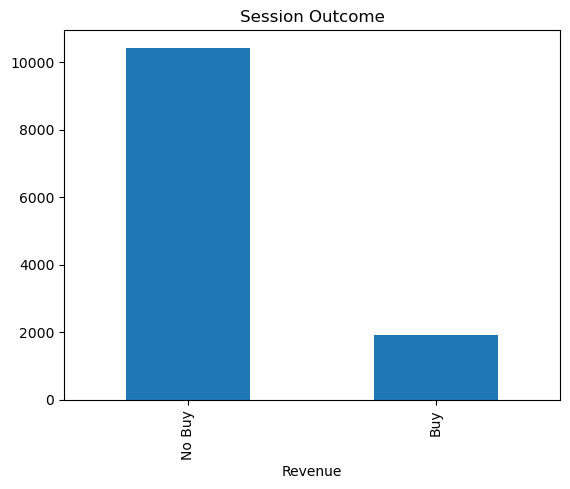

In [9]:
label_map = {True: 'Buy', False: 'No Buy'}

df['Revenue'].map(label_map).value_counts().plot(
    kind = 'bar',
    title="Session Outcome"
)
plt.show()

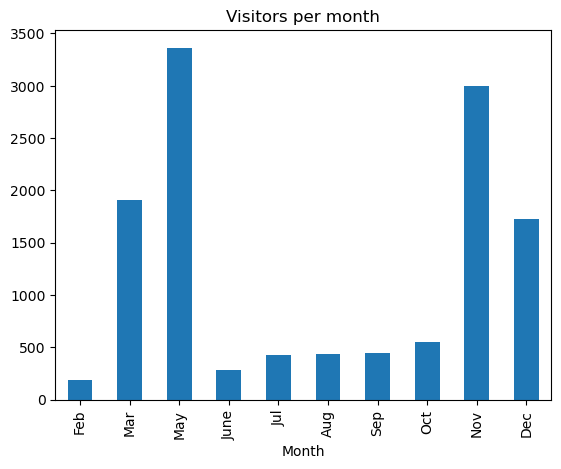

In [10]:
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
df['Month'].value_counts().sort_index().plot(kind="bar")
plt.title('Visitors per month')
plt.show()

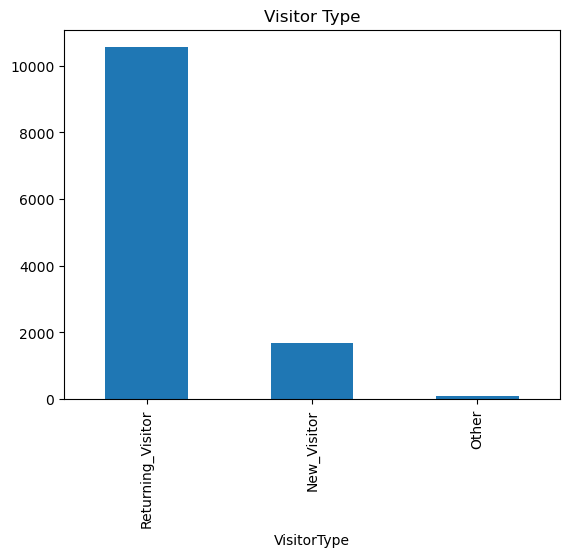

In [11]:
df['VisitorType'].value_counts().plot(kind="bar")
plt.title('Visitor Type')
plt.show()

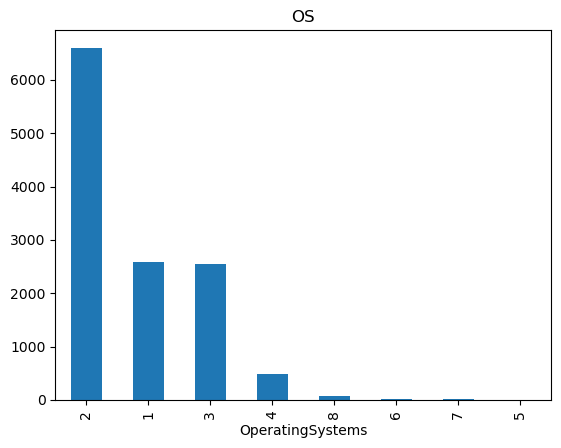

In [12]:
df['OperatingSystems'].value_counts().plot(kind="bar")
plt.title('OS')
plt.show()

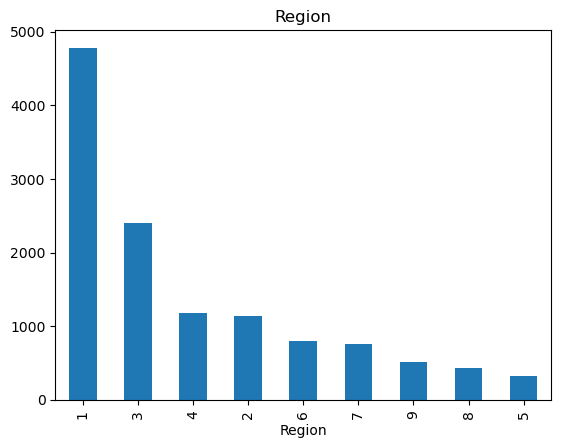

In [13]:
df['Region'].value_counts().plot(kind="bar")
plt.title('Region')
plt.show()

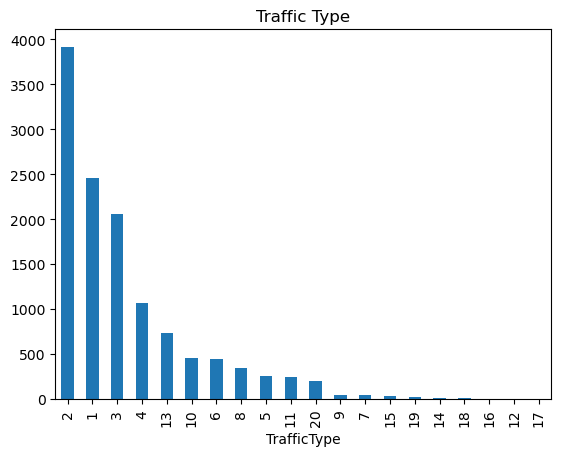

In [14]:
df['TrafficType'].value_counts().plot(kind="bar")
plt.title('Traffic Type')
plt.show()

### Buyer Sessions Analysis

To better understand the profile of users who completed a purchase, we filter the dataset to retain only sessions where `Revenue` is `True`, creating a dedicated subset for buyer-specific analysis.

In [15]:
buyers_df = df[df['Revenue']==True].copy()

In [16]:
buyers_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
65,3,87.83,0,0.00,27,798.33,0.00,0.01,22.92,0.80,Feb,2,2,3,1,Returning_Visitor,False,True
76,10,1005.67,0,0.00,36,2111.34,0.00,0.01,11.44,0.00,Feb,2,6,1,2,Returning_Visitor,False,True
101,4,61.00,0,0.00,19,607.00,0.00,0.03,17.54,1.00,Feb,1,1,7,4,Returning_Visitor,True,True
188,9,111.50,1,48.50,49,1868.82,0.00,0.02,1.71,0.00,Mar,2,2,7,2,Returning_Visitor,False,True
196,2,56.00,1,144.00,67,2563.78,0.00,0.01,19.34,0.00,Mar,2,2,4,2,New_Visitor,False,True


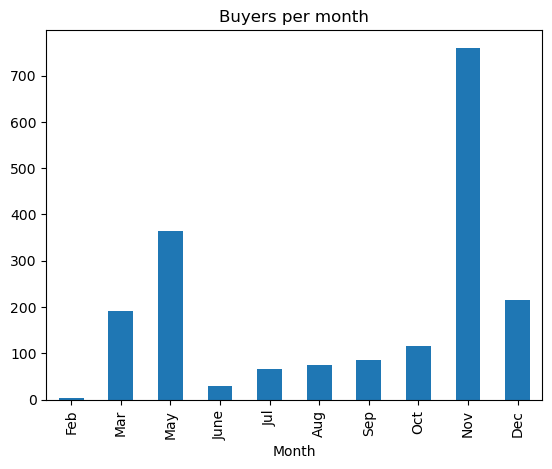

In [17]:
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
buyers_df['Month'] = pd.Categorical(buyers_df['Month'], categories=month_order, ordered=True)
buyers_df['Month'].value_counts().sort_index().plot(kind="bar")
plt.title('Buyers per month')
plt.show()

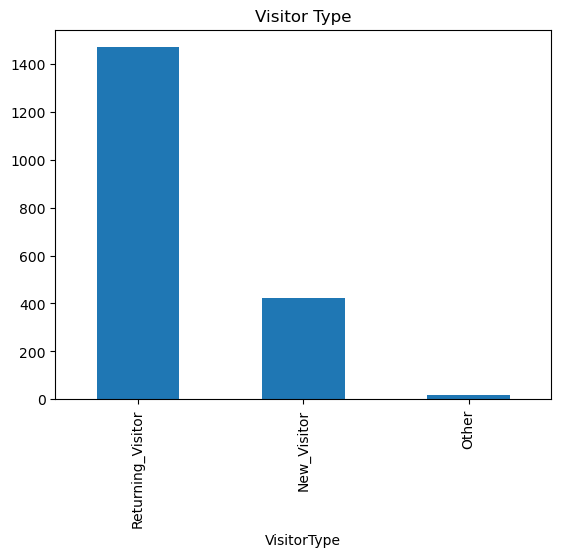

In [18]:
buyers_df['VisitorType'].value_counts().plot(kind="bar")
plt.title('Visitor Type')
plt.show()

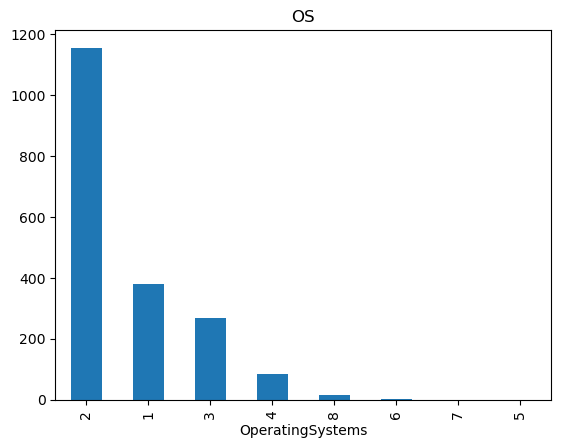

In [19]:
buyers_df['OperatingSystems'].value_counts().plot(kind="bar")
plt.title('OS')
plt.show()

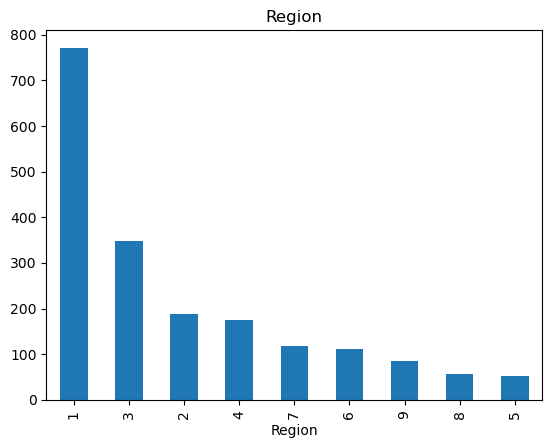

In [20]:
buyers_df['Region'].value_counts().plot(kind="bar")
plt.title('Region')
plt.show()

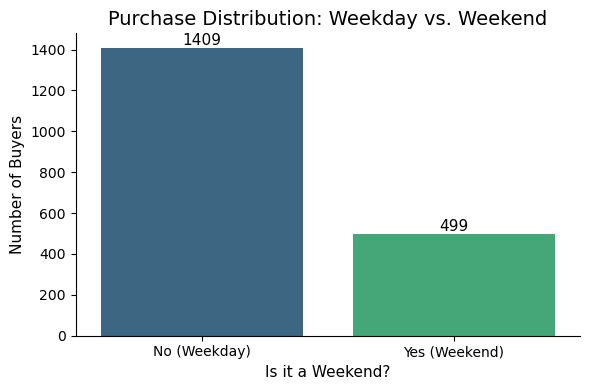

In [22]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=buyers_df, 
    x='Weekend', 
    hue='Weekend', 
    palette='viridis', 
    legend=False
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11
    )

ax.set_title('Purchase Distribution: Weekday vs. Weekend', fontsize=14)
ax.set_xlabel('Is it a Weekend?', fontsize=11)
ax.set_ylabel('Number of Buyers', fontsize=11)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No (Weekday)', 'Yes (Weekend)'])
sns.despine()

plt.tight_layout()
plt.show()

In [20]:
buyers_df.shape

(1908, 18)

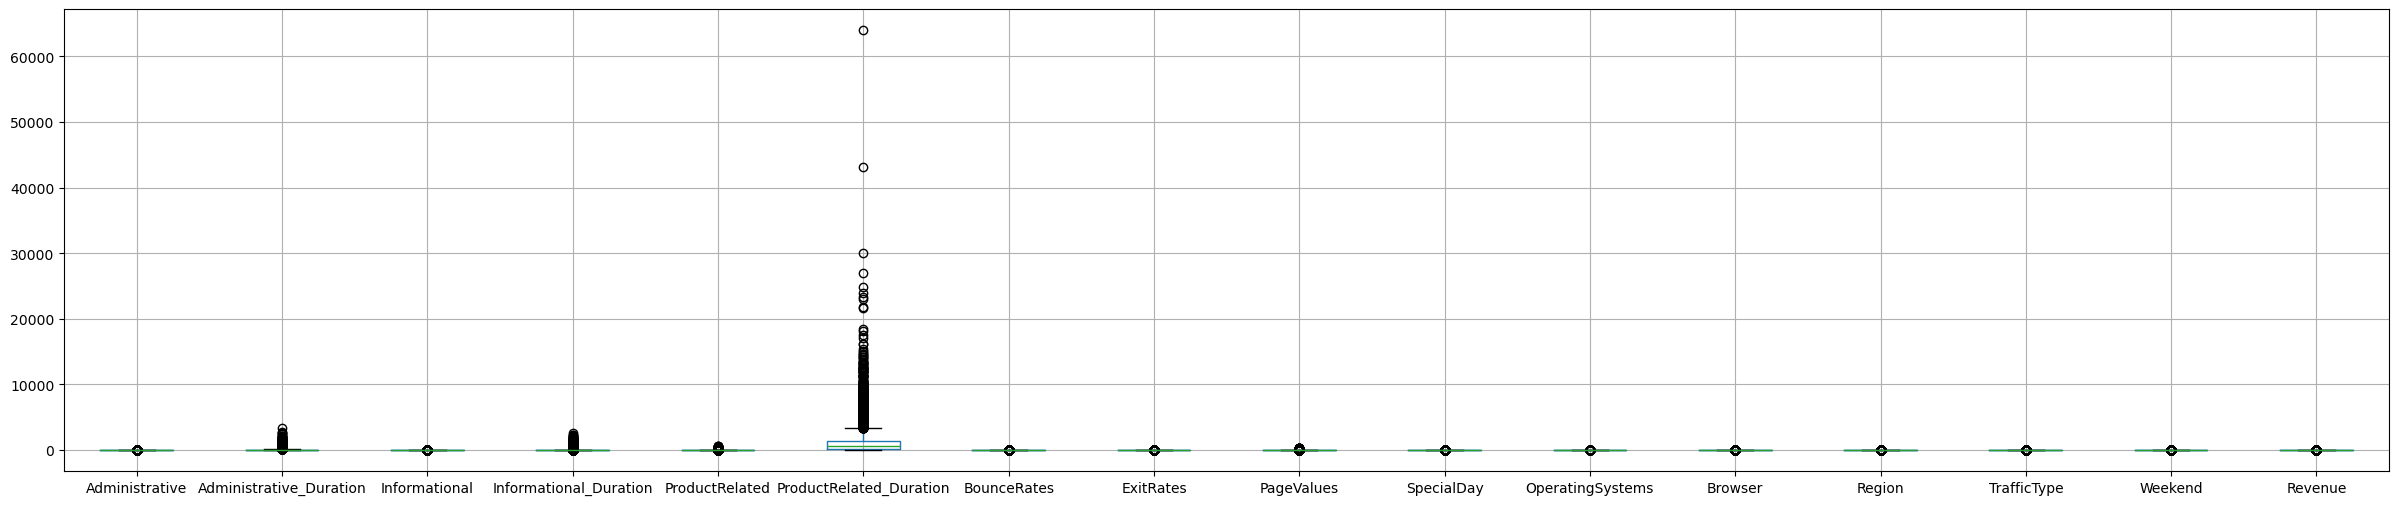

In [21]:
plt.figure(figsize=(30, 6))
df.boxplot()
plt.show()

In [22]:
df[df['ProductRelated_Duration'] > 3600].shape[0]

867

In [23]:
df[df['ProductRelated_Duration'] > 3600].shape[0]/df.shape[0]*100

7.031630170316301

## Data Processing

In this section, the dataset is prepared for model training. Categorical variables `Month` and `VisitorType` are converted into numerical format using **One-Hot Encoding** via `pd.get_dummies()`, creating binary columns for each category. This ensures the Logistic Regression model can properly interpret these features.

In [24]:
processed_df = pd.get_dummies(df, columns=['Month', 'VisitorType'])

In [25]:
processed_df.head(100)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_June,Month_Jul,Month_Aug,Month_Sep,Month_Oct,Month_Nov,Month_Dec,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
1,0,0.00,0,0.00,2,64.00,0.00,0.10,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
2,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
3,0,0.00,0,0.00,2,2.67,0.05,0.14,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
4,0,0.00,0,0.00,10,627.50,0.02,0.05,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0.00,0,0.00,2,33.00,0.00,0.10,0.00,0.20,...,False,False,False,False,False,False,False,False,False,True
96,0,0.00,0,0.00,6,1566.50,0.05,0.07,0.00,0.20,...,False,False,False,False,False,False,False,False,False,True
97,0,0.00,0,0.00,4,105.00,0.00,0.03,0.00,0.60,...,False,False,False,False,False,False,False,False,False,True
98,0,0.00,1,0.00,7,50.00,0.04,0.08,0.00,0.60,...,False,False,False,False,False,False,False,False,False,True


In [26]:
processed_df.shape

(12330, 29)

In [27]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

In [28]:
processed_df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00
mean,2.32,80.82,0.50,34.47,31.73,1194.75,0.02,0.04,5.89,0.06,2.12,2.36,3.15,4.07
std,3.32,176.78,1.27,140.75,44.48,1913.67,0.05,0.05,18.57,0.20,0.91,1.72,2.40,4.03
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,7.00,184.14,0.00,0.01,0.00,0.00,2.00,2.00,1.00,2.00
50%,1.00,7.50,0.00,0.00,18.00,598.94,0.00,0.03,0.00,0.00,2.00,2.00,3.00,2.00
75%,4.00,93.26,0.00,0.00,38.00,1464.16,0.02,0.05,0.00,0.00,3.00,2.00,4.00,4.00
max,27.00,3398.75,24.00,2549.38,705.00,63973.52,0.20,0.20,361.76,1.00,8.00,13.00,9.00,20.00


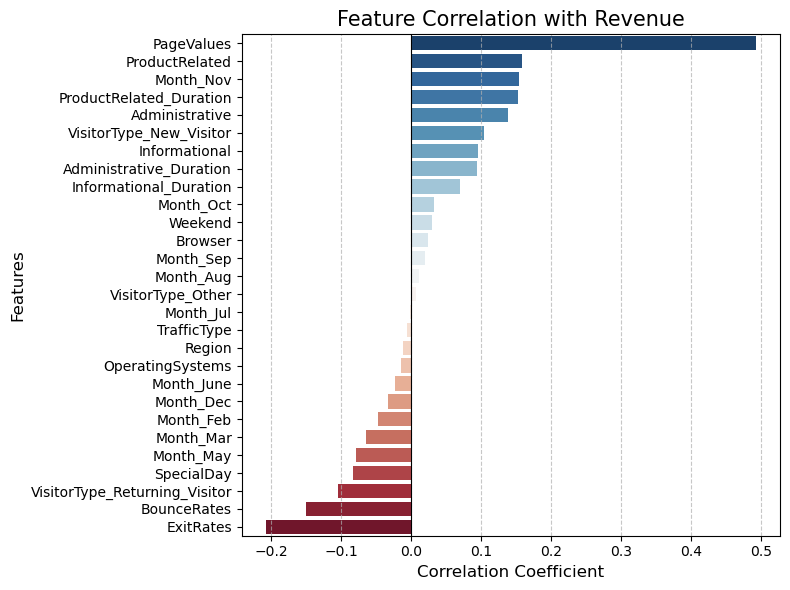

In [26]:
correlations = processed_df.corr(numeric_only=True)['Revenue'].sort_values(ascending=False)
correlations = correlations.drop('Revenue')

plt.figure(figsize=(8, 6))
sns.barplot(x=correlations.values, y=correlations.index, hue=correlations.index, palette='RdBu_r', legend=False)

plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Revenue', fontsize=15)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [27]:
correlations_values = processed_df.corr(numeric_only=True)['Revenue'].sort_values(ascending=False)
correlations_values = correlations_values.drop('Revenue')

print("Feature Correlation with Revenue:")
print(correlations_values)

Feature Correlation with Revenue:
PageValues                       0.49
ProductRelated                   0.16
Month_Nov                        0.15
ProductRelated_Duration          0.15
Administrative                   0.14
VisitorType_New_Visitor          0.10
Informational                    0.10
Administrative_Duration          0.09
Informational_Duration           0.07
Month_Oct                        0.03
Weekend                          0.03
Browser                          0.02
Month_Sep                        0.02
Month_Aug                        0.01
VisitorType_Other                0.01
Month_Jul                       -0.00
TrafficType                     -0.01
Region                          -0.01
OperatingSystems                -0.01
Month_June                      -0.02
Month_Dec                       -0.03
Month_Feb                       -0.05
Month_Mar                       -0.06
Month_May                       -0.08
SpecialDay                      -0.08
VisitorType_Retu

## Model Training and Evaluation

In this section, the dataset is split into training and test sets using a 70/30 ratio with stratification to preserve class proportions. SMOTE is then applied exclusively on the training set to address class imbalance. A Logistic Regression model is trained using a Scikit-learn Pipeline, which ensures the StandardScaler is fitted only on training data, preventing data leakage.

In [28]:
X = processed_df.drop('Revenue', axis=1)
y = processed_df['Revenue']

<Axes: xlabel='Revenue'>

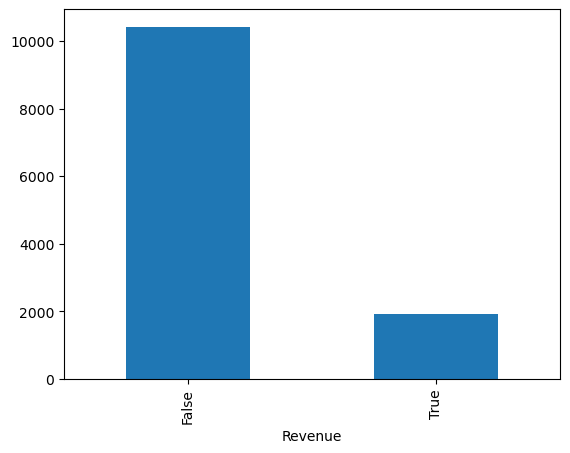

In [31]:
y.value_counts().plot(kind = 'bar')

In [32]:
y.shape

(12330,)

<Axes: xlabel='Revenue'>

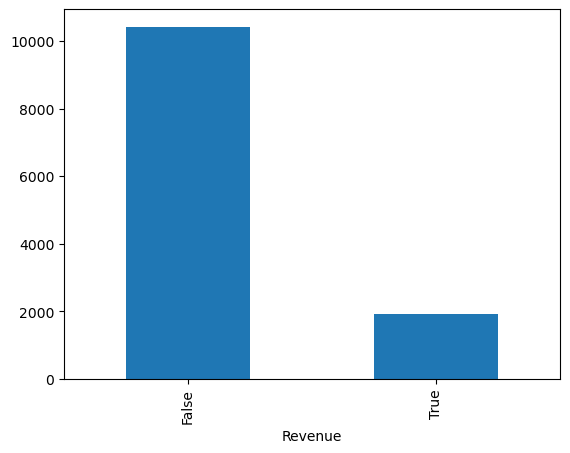

In [33]:
y.value_counts().plot(kind = 'bar')

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=42,
    stratify=y
)

balanceador = SMOTE(random_state=42)
X_train_res, y_train_res = balanceador.fit_resample(X_train, y_train)

print(f"Training set size after SMOTE: {X_train_res.shape}")
print(f"Class distribution after SMOTE: {y_train_res.value_counts().to_dict()}")

Training set size after SMOTE: (14590, 28)
Class distribution after SMOTE: {False: 7295, True: 7295}


In [36]:
X_train.shape

(8631, 28)

In [37]:
y_train.shape

(8631,)

In [111]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(), RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
))

model.fit(X_train_res, y_train_res)

,steps,"[('standardscaler', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2


In [112]:
y_pred = model.predict(X_test)

In [113]:
model.score(X_test,y_test)

0.878345498783455

In [114]:
model.predict_proba(X_test)

array([[0.96832251, 0.03167749],
       [0.99553846, 0.00446154],
       [0.4088065 , 0.5911935 ],
       ...,
       [0.92861287, 0.07138713],
       [0.82421751, 0.17578249],
       [0.89031217, 0.10968783]], shape=(3699, 2))

1. Precision (Precisão)
Responde: "De todos os clientes que o modelo disse que iam comprar, quantos realmente compraram?"

Se for alta: O modelo é cauteloso. Quando ele diz "vai comprar", ele costuma estar certo.

Se for baixa: O modelo dá muitos "alarmes falsos" (Falsos Positivos).

2. Recall (Revocação)
Responde: "De todos os clientes que realmente compraram, quantos o modelo conseguiu identificar?"

Se for alta: O modelo consegue "pescar" quase todos os compradores reais.

Se for baixa: O modelo está a deixar passar muitos compradores (Falsos Negativos), perdendo oportunidades de conversão.

3. F1-Score
É a média harmônica entre a Precisão e o Recall. É a melhor métrica para observar quando você busca um equilíbrio entre não dar alarmes falsos e não ignorar compradores reais.

4. Support (Suporte)
Indica a quantidade de exemplos reais de cada classe no seu conjunto de teste (y_test).

No dataset online_shoppers_intention.csv, o suporte para a classe False (não comprou) é muito maior que para a classe True (comprou), refletindo o desequilíbrio real do mercado (aprox. 84,5% vs 15,5%).

In [115]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.95      0.90      0.93      3127
        True       0.58      0.74      0.65       572

    accuracy                           0.88      3699
   macro avg       0.77      0.82      0.79      3699
weighted avg       0.89      0.88      0.88      3699



In [116]:
y_proba = model.predict_proba(X_test)[:, 1]

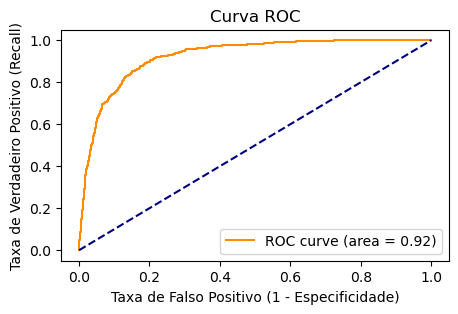

In [117]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calcula a curva
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plota a Curva ROC
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Recall)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

Melhor Threshold: 0.6263
Maior F1-Score atingido: 0.6723


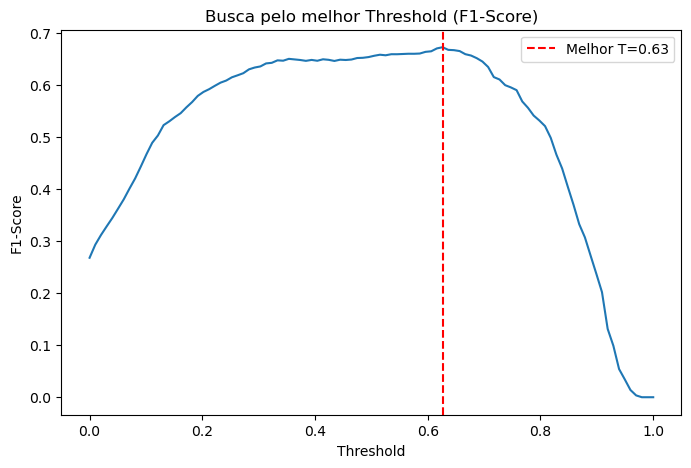

In [118]:
from sklearn.metrics import f1_score
import numpy as np

# Criamos uma lista de possíveis thresholds de 0.01 até 0.99
lista_thresholds = np.linspace(0, 1, 100)
f1_scores = []

for t in lista_thresholds:
    # Se a probabilidade for maior que 't', classifica como True
    y_pred_temp = (y_proba >= t)
    f1_scores.append(f1_score(y_test, y_pred_temp))

# Encontra o índice do maior F1
idx_melhor_t = np.argmax(f1_scores)
melhor_threshold = lista_thresholds[idx_melhor_t]
maior_f1 = f1_scores[idx_melhor_t]

print(f"Melhor Threshold: {melhor_threshold:.4f}")
print(f"Maior F1-Score atingido: {maior_f1:.4f}")

# Gráfico da busca pelo melhor threshold
plt.figure(figsize=(8, 5))
plt.plot(lista_thresholds, f1_scores)
plt.axvline(melhor_threshold, color='red', linestyle='--', label=f'Melhor T={melhor_threshold:.2f}')
plt.title('Busca pelo melhor Threshold (F1-Score)')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.legend()
plt.show()

In [119]:
from sklearn.metrics import classification_report

# Aplicando o melhor threshold encontrado
y_pred_otimizado = (y_proba >= melhor_threshold)

print("Relatório de Classificação com Threshold Otimizado:")
print(classification_report(y_test, y_pred_otimizado))

Relatório de Classificação com Threshold Otimizado:
              precision    recall  f1-score   support

       False       0.94      0.93      0.94      3127
        True       0.65      0.70      0.67       572

    accuracy                           0.90      3699
   macro avg       0.80      0.81      0.80      3699
weighted avg       0.90      0.90      0.90      3699



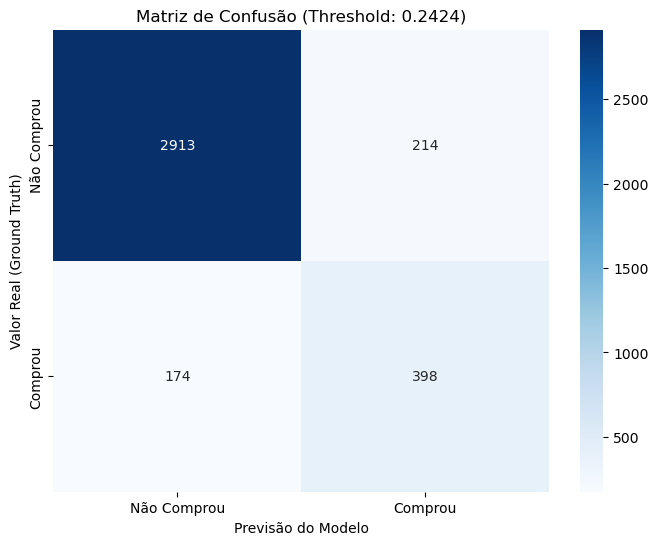

In [120]:
from sklearn.metrics import confusion_matrix

# 1. Gerar as previsões usando o threshold otimizado
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_otimizado = (y_proba >= melhor_threshold)

# 2. Criar a matriz
cm = confusion_matrix(y_test, y_pred_otimizado)

# 3. Plotar usando o Seaborn para ficar visual
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Não Comprou', 'Comprou'], 
            yticklabels=['Não Comprou', 'Comprou'])

plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real (Ground Truth)')
plt.title('Matriz de Confusão (Threshold: 0.2424)')
plt.show()

In [121]:
importances = model.named_steps['randomforestclassifier'].feature_importances_

features = X_train.columns

importancia_df = pd.DataFrame({
    'Feature': features,
    'Importância': importances
}).sort_values(by='Importância', ascending=False)

print(importancia_df)

                          Feature  Importância
8                      PageValues         0.54
7                       ExitRates         0.08
23                      Month_Nov         0.07
5         ProductRelated_Duration         0.05
1         Administrative_Duration         0.03
25        VisitorType_New_Visitor         0.03
4                  ProductRelated         0.03
6                     BounceRates         0.03
0                  Administrative         0.02
27  VisitorType_Returning_Visitor         0.01
3          Informational_Duration         0.01
10               OperatingSystems         0.01
14                        Weekend         0.01
21                      Month_Sep         0.01
13                    TrafficType         0.01
22                      Month_Oct         0.01
12                         Region         0.01
17                      Month_May         0.01
2                   Informational         0.01
16                      Month_Mar         0.01
24           

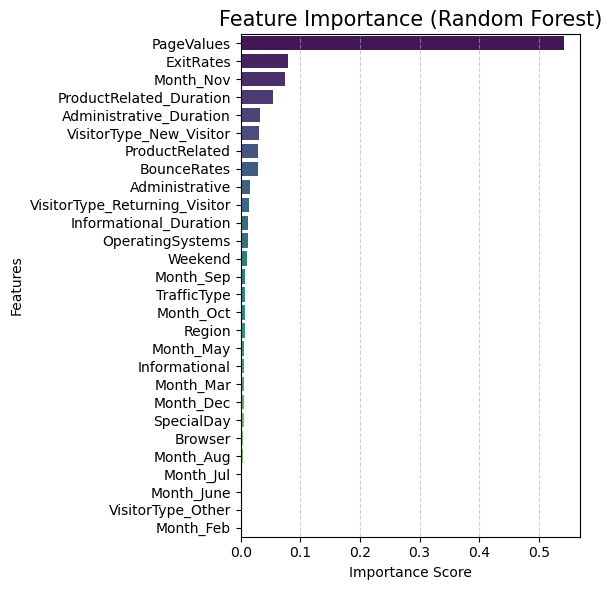

In [122]:
plt.figure(figsize=(6, 6))
sns.barplot(
    data=importancia_df,
    x='Importância',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('Feature Importance (Random Forest)', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [123]:
## Score Treino vs Teste

print(f"Score Treino: {model.score(X_train, y_train):.4f}")
print(f"Score Teste:  {model.score(X_test, y_test):.4f}")


Score Treino: 0.9040
Score Teste:  0.8783
